<a href="https://colab.research.google.com/github/AHMEDVALL70/ahmed-vall-cv/blob/main/Crypto_Price_Predictor_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Project 09: Cryptocurrency Price Predictor (LSTM)

**Author:** Ahmed Vall Jemal Dine Sidina | AHMEDVALL70

**Context:** Applying deep learning to financial time-series data — extending procurement and budget management expertise into predictive financial modeling.

**Goal:** Use LSTM (Long Short-Term Memory) recurrent neural networks to predict cryptocurrency price movements based on historical data.

**Algorithm:** LSTM · Deep Learning · Time-Series Analysis

**Use Cases:** Crypto trading signals · Financial forecasting · Risk assessment

🚀 بدء التدريب...
Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3127
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1280
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0865
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0538
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0301
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0178
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0139
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0132
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0131
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0130
✅ Final Loss (MSE): 0.0130


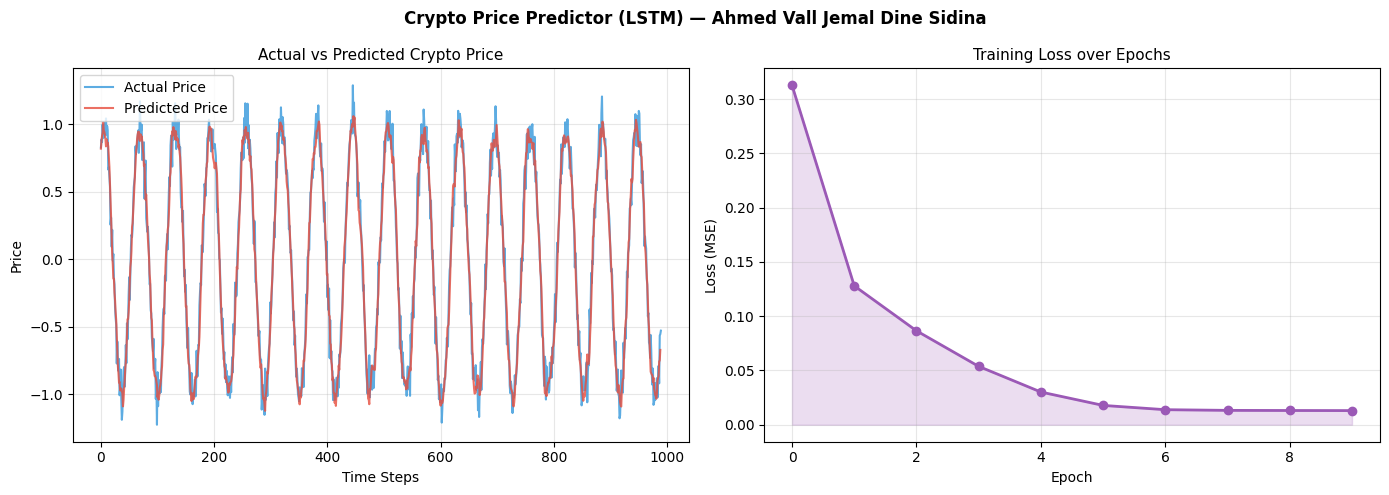

✅ تم حفظ الرسم البياني!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# ── البيانات ──
data = np.sin(np.linspace(0, 100, 1000)) + np.random.normal(0, 0.1, 1000)

def create_dataset(dataset, look_back=10):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        X.append(dataset[i:(i+look_back)])
        Y.append(dataset[i + look_back])
    return np.array(X), np.array(Y)

look_back = 10
X, y = create_dataset(data, look_back)
X = np.reshape(X, (X.shape[0], 1, X.shape[1]))

# ── النموذج ──
model = Sequential([
    Input(shape=(1, look_back)),
    LSTM(50),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
print("🚀 بدء التدريب...")
history_obj = model.fit(X, y, epochs=10, batch_size=32, verbose=1)

# ── التوقعات ──
predictions = model.predict(X, verbose=0)
final_loss = history_obj.history['loss'][-1]
print(f"✅ Final Loss (MSE): {final_loss:.4f}")

# ── الرسم البياني ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Crypto Price Predictor (LSTM) — Ahmed Vall Jemal Dine Sidina',
             fontsize=12, fontweight='bold')

# 1️⃣ Actual vs Predicted
axes[0].plot(data[look_back:], color='#3498db',
             linewidth=1.5, label='Actual Price', alpha=0.8)
axes[0].plot(predictions, color='#e74c3c',
             linewidth=1.5, label='Predicted Price', alpha=0.8)
axes[0].set_title('Actual vs Predicted Crypto Price', fontsize=11)
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2️⃣ منحنى الخسارة
axes[1].plot(history_obj.history['loss'],
             color='#9b59b6', linewidth=2, marker='o')
axes[1].set_title('Training Loss over Epochs', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(range(len(history_obj.history['loss'])),
                      history_obj.history['loss'],
                      alpha=0.2, color='#9b59b6')

plt.tight_layout()
plt.savefig('crypto_price_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ تم حفظ الرسم البياني!")